In [1]:
!pip install shap lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import pickle
import numpy as np
import pandas as pd
import shap
import lime
import lime.lime_text
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline

In [5]:
save_dir = "/content/drive/MyDrive/ExAI/models"

with open(f"{save_dir}/base_models.pkl", "rb") as f:
    base_models = pickle.load(f)

with open(f"{save_dir}/meta_model.pkl", "rb") as f:
    meta_model = pickle.load(f)

with open(f"{save_dir}/tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

combined = pd.read_csv("/content/drive/MyDrive/ExAI/combined.csv")
combined["content"] = combined["title"].astype(str) + " " + combined["text"].astype(str)

print("Models and data loaded successfully.")

Models and data loaded successfully.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
def stack_predict_proba(texts):
    vecs = vectorizer.transform(texts)
    base_preds = np.column_stack([
        model.predict_proba(vecs)[:, 1]
        for model in base_models.values()
    ])
    return meta_model.predict_proba(base_preds)

def stack_predict(texts):
    return meta_model.predict(
        np.column_stack([
            model.predict_proba(vectorizer.transform(texts))[:, 1]
            for model in base_models.values()
        ])
    )

# Quick sanity check
sample = combined["content"].iloc[:3].tolist()
print("Sample predictions:", stack_predict(sample))
print("Sample probabilities:\n", stack_predict_proba(sample))

Sample predictions: [1 1 0]
Sample probabilities:
 [[0.08160779 0.91839221]
 [0.01215702 0.98784298]
 [0.9892096  0.0107904 ]]


---
## Part 1 — SHAP Explanations

In [7]:
logreg_model = base_models["LogReg"]

sample_size = 500
background = vectorizer.transform(
    combined["content"].sample(sample_size, random_state=23)
)

explainer_shap = shap.LinearExplainer(logreg_model, background, feature_perturbation="interventional")

test_subset = combined["content"].sample(200, random_state=42)
test_subset_vec = vectorizer.transform(test_subset)
shap_values = explainer_shap.shap_values(test_subset_vec)

print(f"SHAP values computed for {len(test_subset)} samples.")

SHAP values computed for 200 samples.


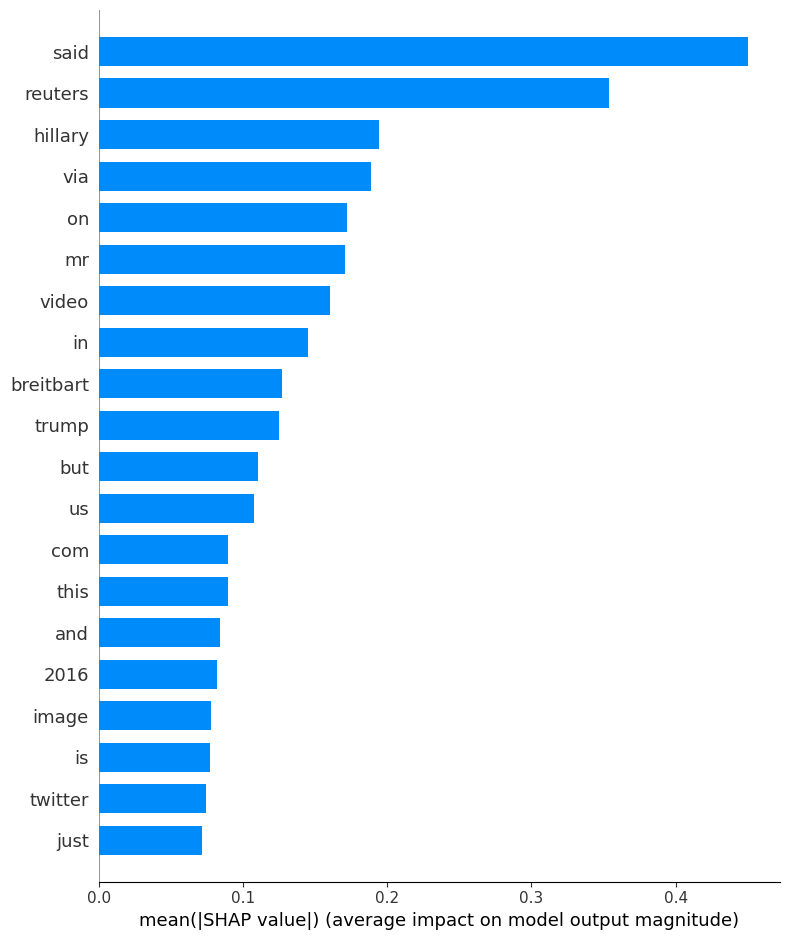

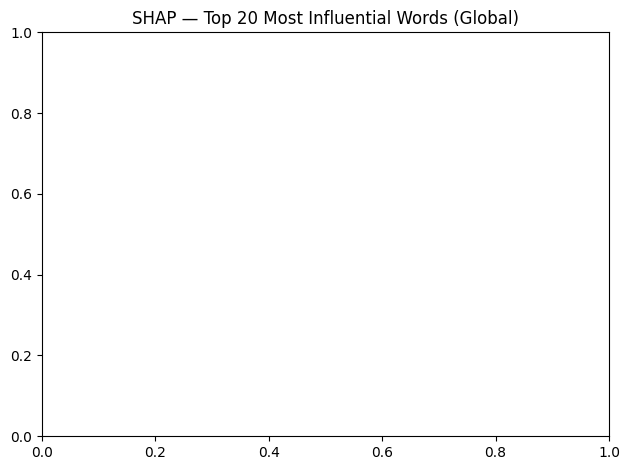

In [8]:
feature_names = vectorizer.get_feature_names_out()

shap.summary_plot(
    shap_values,
    test_subset_vec,
    feature_names=feature_names,
    max_display=20,
    plot_type="bar",
    show=True
)
plt.title("SHAP — Top 20 Most Influential Words (Global)")
plt.tight_layout()
plt.show()

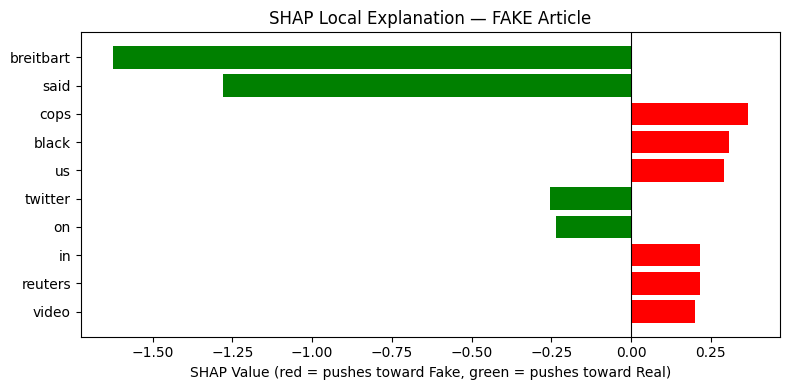

Article: FAKE
Prediction: Fake | Confidence: 91.84%
Preview: LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #F...



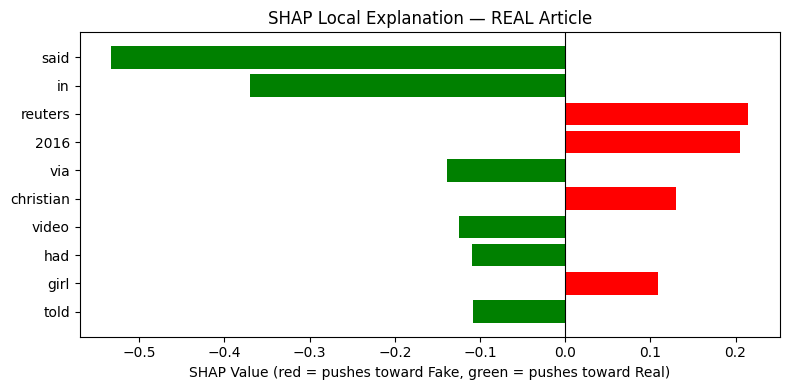

Article: REAL
Prediction: Real | Confidence: 98.92%
Preview: Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid A dozen politically active pastors came here for a private dinner Friday night to hear a conve...



In [9]:
fake_sample = combined[combined["label"] == 1]["content"].iloc[0]
real_sample = combined[combined["label"] == 0]["content"].iloc[0]

for label, text in [("FAKE", fake_sample), ("REAL", real_sample)]:
    vec = vectorizer.transform([text])
    sv  = explainer_shap.shap_values(vec)[0]

    top_idx    = np.argsort(np.abs(sv))[-10:][::-1]
    top_words  = [feature_names[i] for i in top_idx]
    top_values = [sv[i] for i in top_idx]

    colors = ["red" if v > 0 else "green" for v in top_values]

    plt.figure(figsize=(8, 4))
    plt.barh(top_words[::-1], top_values[::-1], color=colors[::-1])
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"SHAP Local Explanation — {label} Article")
    plt.xlabel("SHAP Value (red = pushes toward Fake, green = pushes toward Real)")
    plt.tight_layout()
    plt.show()

    pred = stack_predict([text])[0]
    prob = stack_predict_proba([text])[0]
    print(f"Article: {label}")
    print(f"Prediction: {'Fake' if pred == 1 else 'Real'} | Confidence: {max(prob):.2%}")
    print(f"Preview: {text[:200]}...")
    print()

---
## Part 2 — LIME Explanations

In [10]:
lime_explainer = lime.lime_text.LimeTextExplainer(
    class_names=["Real", "Fake"],
    random_state=23
)

In [11]:
for label, text in [("FAKE", fake_sample), ("REAL", real_sample)]:
    exp = lime_explainer.explain_instance(
        text,
        stack_predict_proba,
        num_features=10,
        num_samples=500
    )

    print(f"\nLIME Explanation — {label} Article")
    pred = stack_predict([text])[0]
    prob = stack_predict_proba([text])[0]
    print(f"Prediction: {'Fake' if pred == 1 else 'Real'} | Confidence: {max(prob):.2%}")
    exp.show_in_notebook(text=True)
    print()

Output hidden; open in https://colab.research.google.com to view.

---
## Part 3 — SHAP vs LIME Consistency Analysis

Mean SHAP–LIME top-10 word overlap: 14.00%


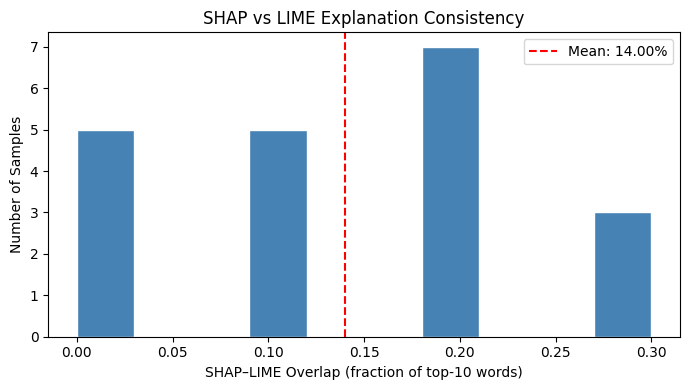

In [12]:
def get_shap_top_words(text, n=10):
    vec = vectorizer.transform([text])
    sv  = explainer_shap.shap_values(vec)[0]
    top_idx = np.argsort(np.abs(sv))[-n:][::-1]
    return set(feature_names[i] for i in top_idx)

def get_lime_top_words(text, n=10):
    exp = lime_explainer.explain_instance(
        text, stack_predict_proba, num_features=n, num_samples=500
    )
    return set(word for word, _ in exp.as_list())

sample_texts = combined["content"].sample(20, random_state=42).tolist()
overlap_scores = []

for text in sample_texts:
    shap_words = get_shap_top_words(text)
    lime_words = get_lime_top_words(text)
    overlap = len(shap_words & lime_words) / 10
    overlap_scores.append(overlap)

mean_overlap = np.mean(overlap_scores)
print(f"Mean SHAP–LIME top-10 word overlap: {mean_overlap:.2%}")

plt.figure(figsize=(7, 4))
plt.hist(overlap_scores, bins=10, color="steelblue", edgecolor="white")
plt.axvline(mean_overlap, color="red", linestyle="--", label=f"Mean: {mean_overlap:.2%}")
plt.xlabel("SHAP–LIME Overlap (fraction of top-10 words)")
plt.ylabel("Number of Samples")
plt.title("SHAP vs LIME Explanation Consistency")
plt.legend()
plt.tight_layout()
plt.show()